# Phase 3 — ML Feature Engineering

This notebook validates the causal and regime-relevant features generated
for the ETF-only and full asset universes.

The objective is to prepare explanatory variables for the Phase 4
market-regime models while preventing lookahead bias.

In [41]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Support execution either from the repository root or from notebooks/.
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data").exists():
    ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists():
    ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "The project data directory could not be found. "
        "Run this notebook from the Portfolio_ML repository."
    )

print(f"Project root: {ROOT}")

Project root: c:\Users\bouaj\Documents\Portfolio_ML


In [42]:
ETF_FEATURES_PATH = ROOT / "data/gold/ml_features_etf.parquet"
FULL_FEATURES_PATH = ROOT / "data/gold/ml_features_full.parquet"
MANIFEST_PATH = ROOT / "data/gold/ml_features_manifest.json"

for path in [
    ETF_FEATURES_PATH,
    FULL_FEATURES_PATH,
    MANIFEST_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(f"Missing Phase 3 artifact: {path}")

etf_features = pd.read_parquet(ETF_FEATURES_PATH)
full_features = pd.read_parquet(FULL_FEATURES_PATH)

with MANIFEST_PATH.open(encoding="utf-8") as file:
    manifest = json.load(file)

print("ETF features:", etf_features.shape)
print("Full-universe features:", full_features.shape)

ETF features: (2415, 13)
Full-universe features: (1250, 13)


## 1. Feature-set validation

The Phase 3 pipeline produces market, risk, dependence and macroeconomic
features. All rolling calculations use current and past observations only.

In [43]:
core_features = [
    "MARKET_RETURN",
    "MARKET_VOL_SHORT",
    "MARKET_VOL_LONG",
    "AVG_PAIRWISE_CORR",
    "CROSS_SECTIONAL_DISPERSION",
    "MARKET_DRAWDOWN",
]

missing_etf = [
    column
    for column in core_features
    if column not in etf_features.columns
]

missing_full = [
    column
    for column in core_features
    if column not in full_features.columns
]

assert not missing_etf, f"Missing ETF features: {missing_etf}"
assert not missing_full, f"Missing full-universe features: {missing_full}"

print("Core feature validation passed.")
print("\nETF columns:")
print(etf_features.columns.tolist())

print("\nFull-universe columns:")
print(full_features.columns.tolist())

Core feature validation passed.

ETF columns:
['MARKET_RETURN', 'MARKET_VOL_SHORT', 'MARKET_VOL_LONG', 'AVG_PAIRWISE_CORR', 'CROSS_SECTIONAL_DISPERSION', 'MARKET_DRAWDOWN', 'VIX_DIFF_L1', 'US10Y_DIFF_L1', 'DXY_DIFF_L1', 'CREDIT_SPREAD_DIFF_L1', 'EURMAD_DIFF_L1', 'USDMAD_DIFF_L1', 'TAUX_DIR_DIFF_L1']

Full-universe columns:
['MARKET_RETURN', 'MARKET_VOL_SHORT', 'MARKET_VOL_LONG', 'AVG_PAIRWISE_CORR', 'CROSS_SECTIONAL_DISPERSION', 'MARKET_DRAWDOWN', 'VIX_DIFF_L1', 'US10Y_DIFF_L1', 'DXY_DIFF_L1', 'CREDIT_SPREAD_DIFF_L1', 'EURMAD_DIFF_L1', 'USDMAD_DIFF_L1', 'TAUX_DIR_DIFF_L1']


## 2. Temporal coverage

In [44]:
coverage = pd.DataFrame(
    {
        "Universe": ["ETF 2017+", "Full 2021+"],
        "Rows": [
            len(etf_features),
            len(full_features),
        ],
        "Columns": [
            etf_features.shape[1],
            full_features.shape[1],
        ],
        "Start": [
            etf_features.index.min(),
            full_features.index.min(),
        ],
        "End": [
            etf_features.index.max(),
            full_features.index.max(),
        ],
    }
)

coverage

,Universe,Rows,Columns,Start,End
0,ETF 2017+,2415,13,2017-03-31,2026-07-02
1,Full 2021+,1250,13,2021-09-28,2026-07-13


## 3. Descriptive statistics

In [45]:
etf_features[core_features].describe().T

,count,mean,std,min,25%,50%,75%,max
MARKET_RETURN,2415.0,0.000400,0.007978,-0.067349,-0.003242,0.000647,0.004381,0.064486
MARKET_VOL_SHORT,2415.0,0.111766,0.059414,0.036686,0.074754,0.098655,0.133849,0.547144
MARKET_VOL_LONG,2415.0,0.114472,0.051042,0.047330,0.081522,0.104355,0.133661,0.341836
AVG_PAIRWISE_CORR,2415.0,0.270159,0.130601,-0.009309,0.172007,0.256827,0.361903,0.671688
CROSS_SECTIONAL_DISPERSION,2415.0,0.007696,0.005903,0.000000,0.004107,0.006435,0.009672,0.087111
MARKET_DRAWDOWN,2415.0,-0.050082,0.061657,-0.269957,-0.068393,-0.023734,-0.004718,0.000000


In [46]:
full_features[core_features].describe().T

,count,mean,std,min,25%,50%,75%,max
MARKET_RETURN,1250.0,0.000174,0.006305,-0.036162,-0.003067,0.000460,0.003620,0.030319
MARKET_VOL_SHORT,1250.0,0.094404,0.032452,0.034716,0.071883,0.086533,0.111514,0.208498
MARKET_VOL_LONG,1250.0,0.095502,0.024946,0.059478,0.074989,0.091520,0.110322,0.164719
AVG_PAIRWISE_CORR,1250.0,0.155216,0.057969,0.004991,0.120669,0.148595,0.183196,0.358124
CROSS_SECTIONAL_DISPERSION,1250.0,0.010285,0.005636,0.000000,0.006505,0.009192,0.012528,0.057002
MARKET_DRAWDOWN,1250.0,-0.070540,0.068404,-0.242561,-0.121702,-0.040506,-0.013719,0.000000


## 4. Short- and long-term market volatility

Short-term volatility reacts quickly to recent shocks, while long-term
volatility describes a more persistent level of market risk.

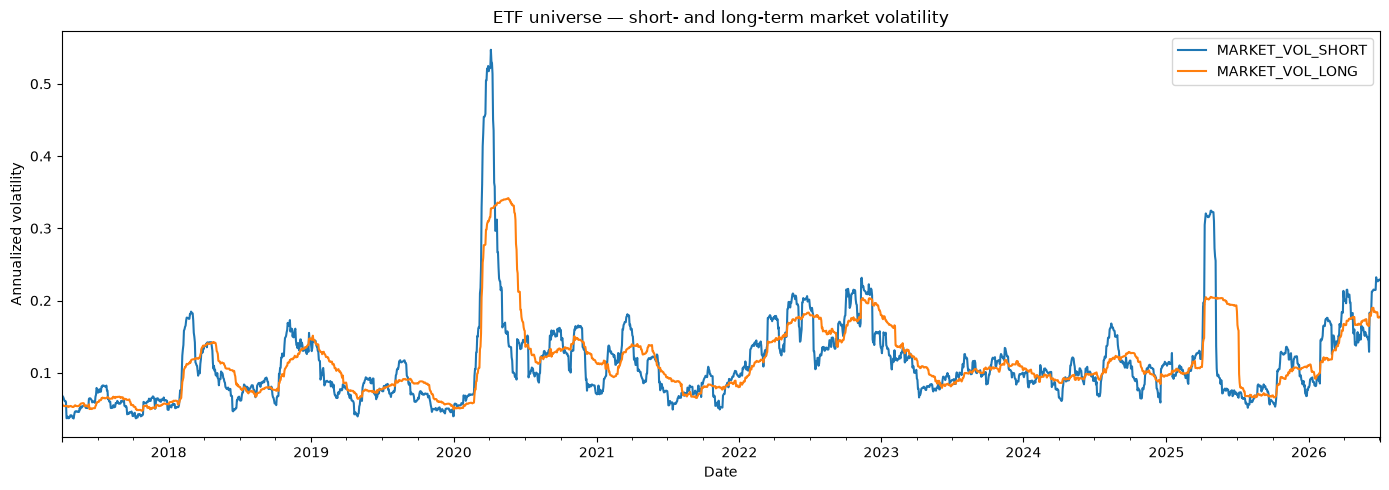

In [47]:
ax = etf_features[
    ["MARKET_VOL_SHORT", "MARKET_VOL_LONG"]
].plot(
    figsize=(14, 5),
    title="ETF universe — short- and long-term market volatility",
)

ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility")
plt.tight_layout()
plt.show()

## 5. Average pairwise correlation

An increase in average cross-asset correlation indicates that diversification
may become less effective, especially during periods of market stress.

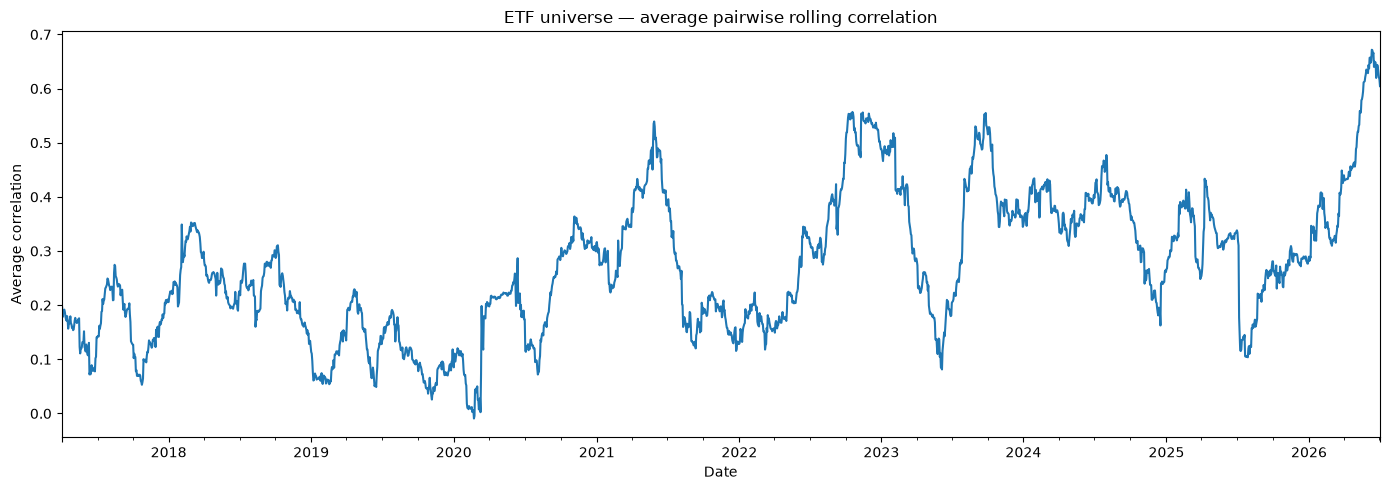

In [48]:
ax = etf_features["AVG_PAIRWISE_CORR"].plot(
    figsize=(14, 5),
    title="ETF universe — average pairwise rolling correlation",
)

ax.set_xlabel("Date")
ax.set_ylabel("Average correlation")
plt.tight_layout()
plt.show()

## 6. Cross-sectional dispersion

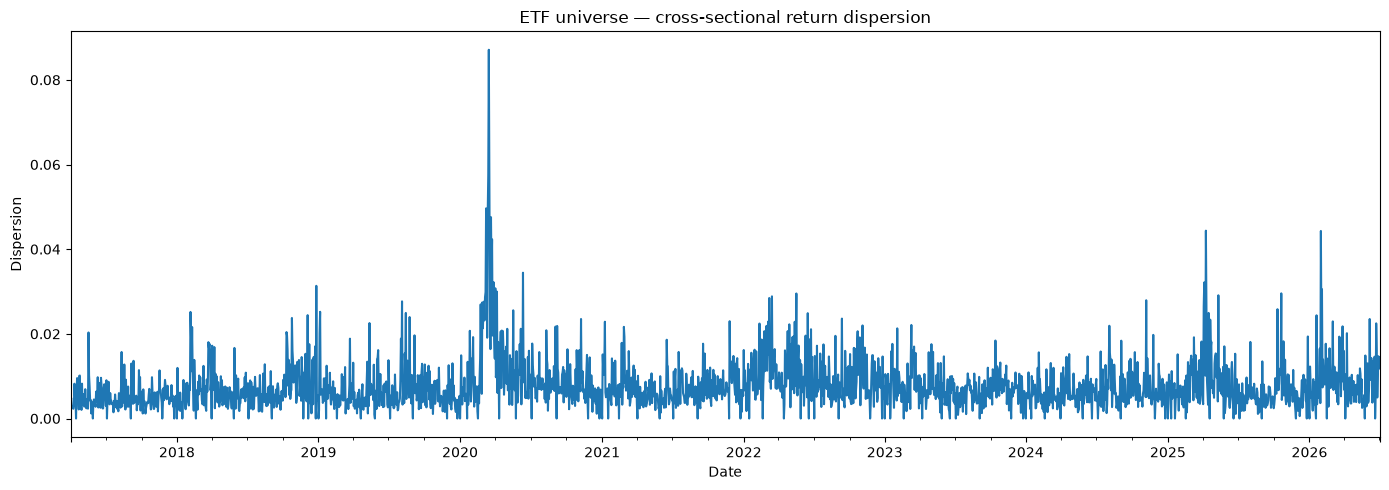

In [49]:
ax = etf_features["CROSS_SECTIONAL_DISPERSION"].plot(
    figsize=(14, 5),
    title="ETF universe — cross-sectional return dispersion",
)

ax.set_xlabel("Date")
ax.set_ylabel("Dispersion")
plt.tight_layout()
plt.show()

## 7. Market drawdown

Drawdown measures the decline of the equal-weight market portfolio from its
previous historical peak.

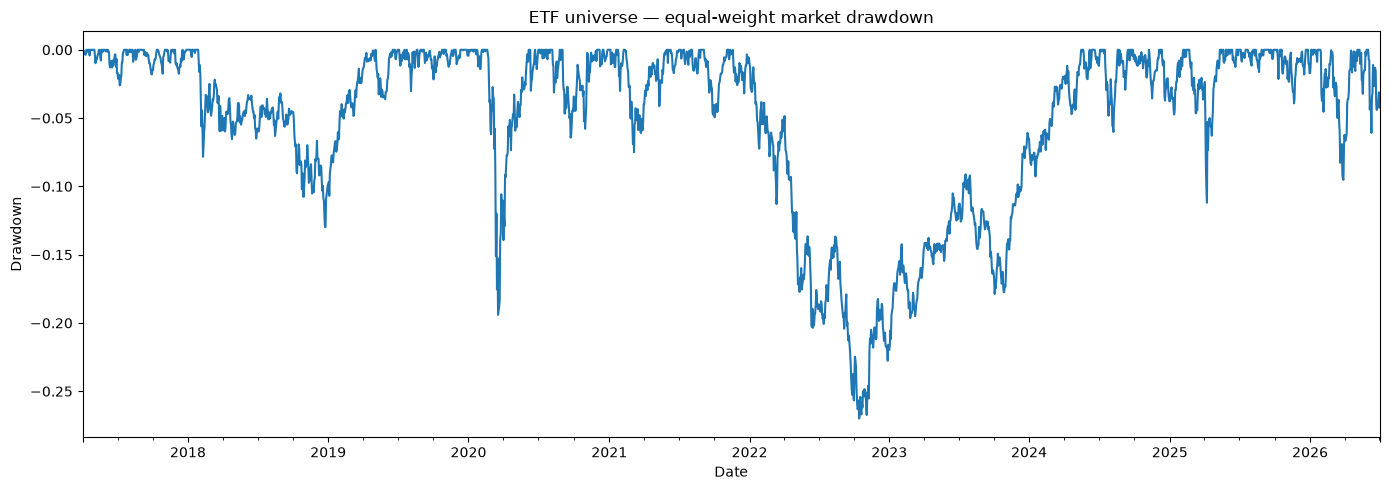

In [50]:
ax = etf_features["MARKET_DRAWDOWN"].plot(
    figsize=(14, 5),
    title="ETF universe — equal-weight market drawdown",
)

ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
plt.tight_layout()
plt.show()

## 8. COVID-19 market shock

The ETF universe contains the 2020 COVID-19 crisis. This period is used to
verify whether the engineered variables capture changes in volatility,
dependence and market losses.

In [51]:
covid_features = etf_features.loc[
    "2020-02-01":"2020-06-30",
    [
        "MARKET_VOL_SHORT",
        "AVG_PAIRWISE_CORR",
        "MARKET_DRAWDOWN",
    ],
]

covid_features

,MARKET_VOL_SHORT,AVG_PAIRWISE_CORR,MARKET_DRAWDOWN
Date,,,
2020-02-03,0.063213,0.051674,-0.009016
2020-02-04,0.067211,0.018280,-0.001734
2020-02-05,0.067098,0.010230,0.000000
2020-02-06,0.068290,0.010735,0.000000
2020-02-07,0.068092,0.007936,-0.001715
...,...,...,...
2020-06-24,0.141092,0.186764,-0.010508
2020-06-25,0.141271,0.188782,-0.005224
2020-06-26,0.145708,0.177357,-0.014143


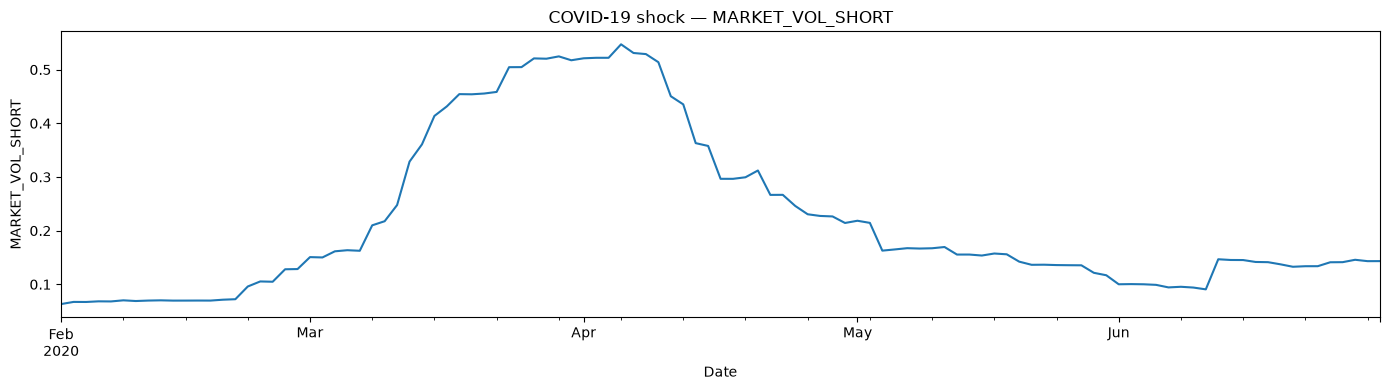

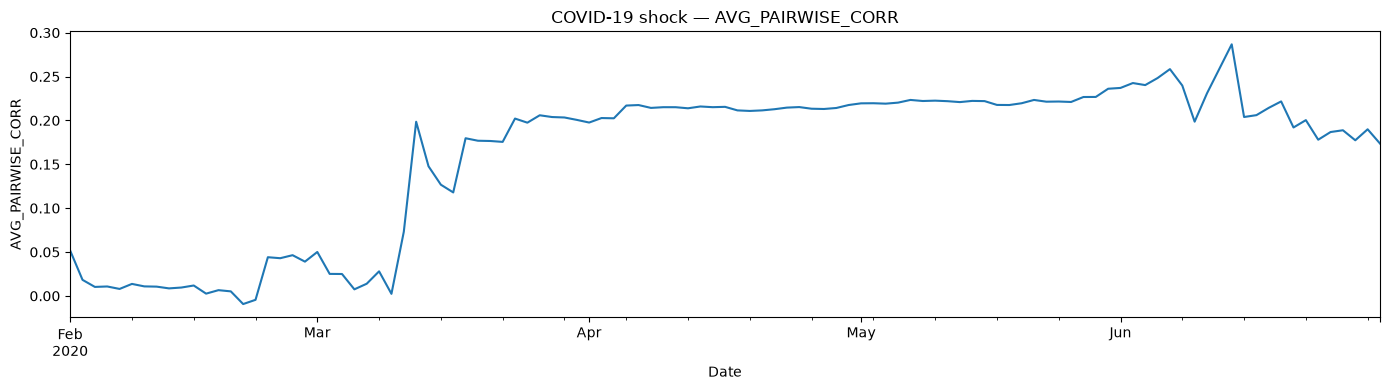

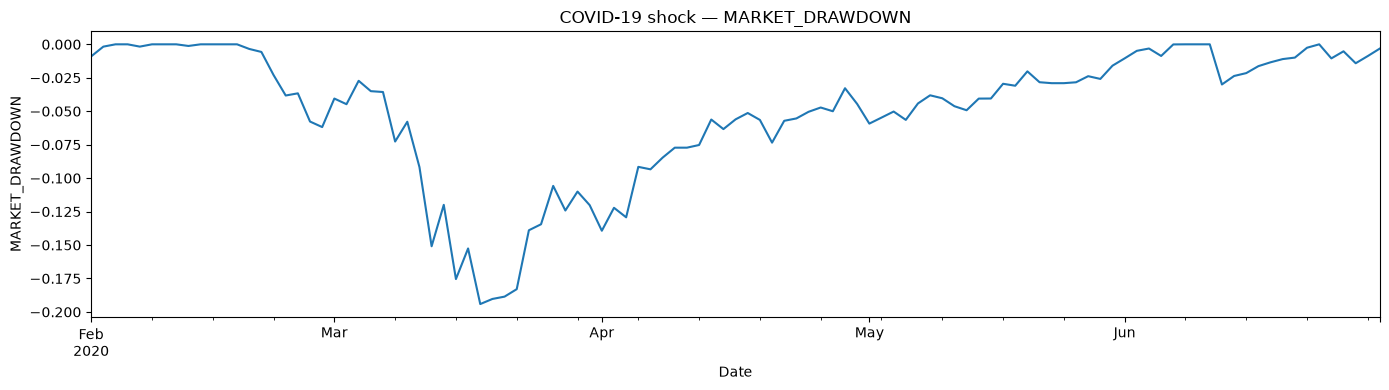

In [52]:
for column in covid_features.columns:
    ax = covid_features[column].plot(
        figsize=(14, 4),
        title=f"COVID-19 shock — {column}",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()

## 9. 2022 rate shock

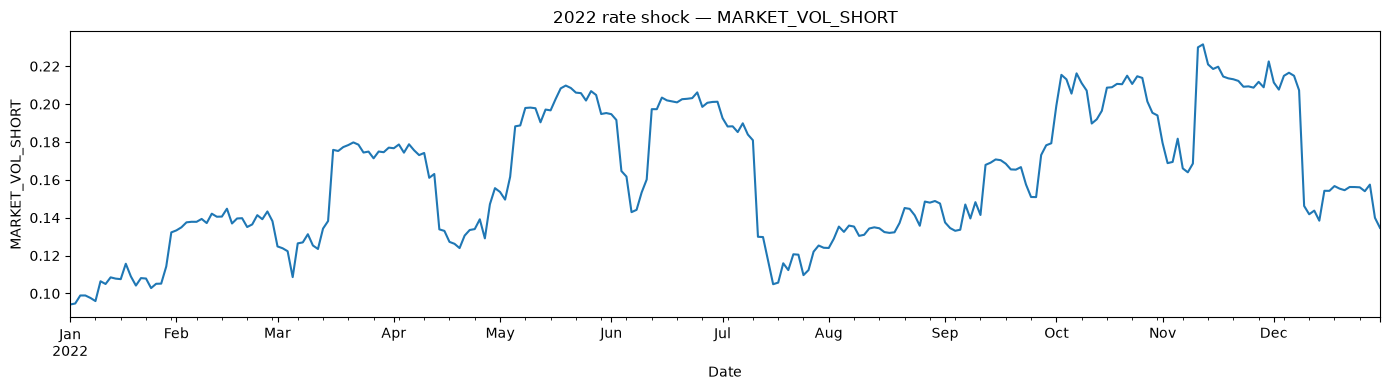

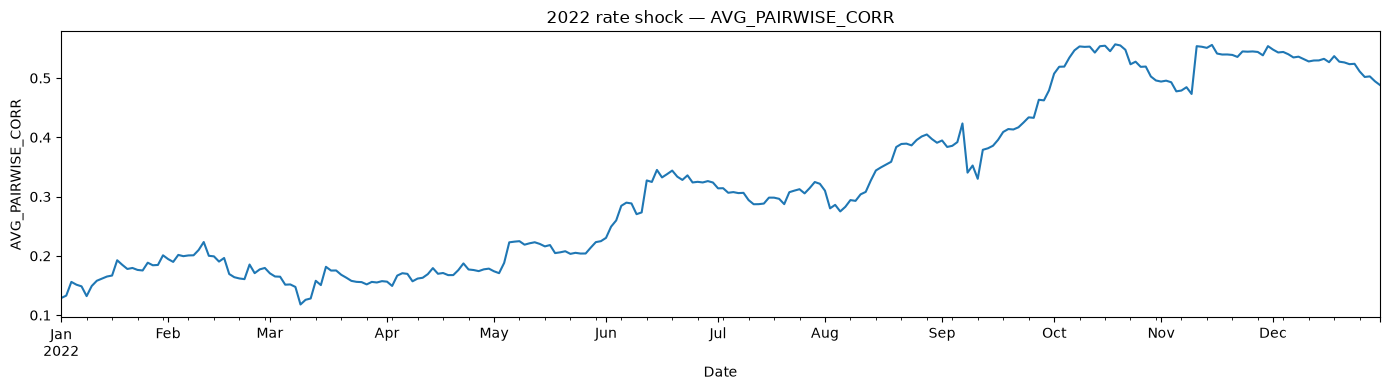

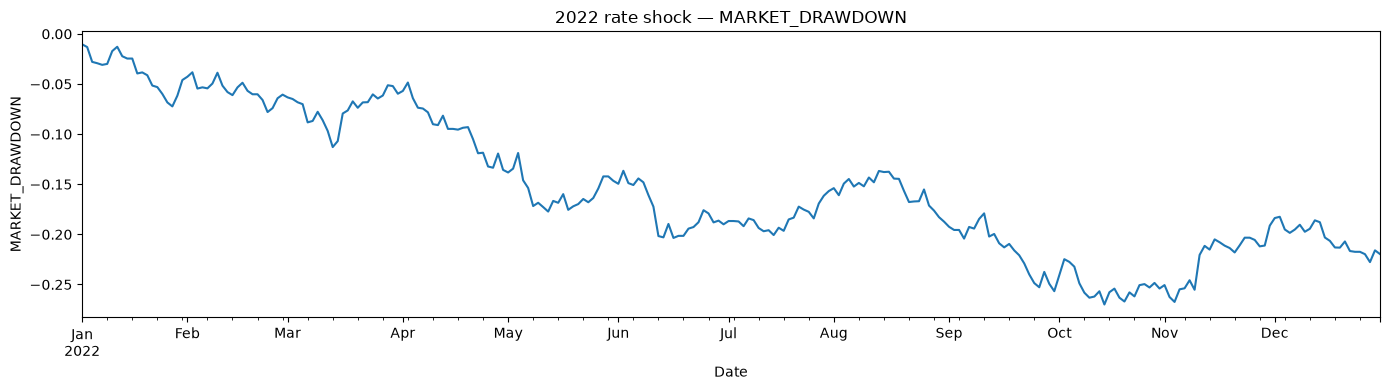

In [53]:
rate_shock_features = etf_features.loc[
    "2022-01-01":"2022-12-31",
    [
        "MARKET_VOL_SHORT",
        "AVG_PAIRWISE_CORR",
        "MARKET_DRAWDOWN",
    ],
]

for column in rate_shock_features.columns:
    ax = rate_shock_features[column].plot(
        figsize=(14, 4),
        title=f"2022 rate shock — {column}",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()

## 10. Lagged macroeconomic signals

Macroeconomic variables are differenced and lagged by at least one day.
They are deliberately not standardized over the complete dataset.
Standardization will be fitted only on each Phase 4 training window.

In [54]:
macro_columns = [
    column
    for column in etf_features.columns
    if column.endswith("_DIFF_L1")
]

macro_columns

['VIX_DIFF_L1',
 'US10Y_DIFF_L1',
 'DXY_DIFF_L1',
 'CREDIT_SPREAD_DIFF_L1',
 'EURMAD_DIFF_L1',
 'USDMAD_DIFF_L1',
 'TAUX_DIR_DIFF_L1']

In [55]:
if macro_columns:
    etf_features[macro_columns].describe().T
else:
    print("No lagged macro columns were found.")

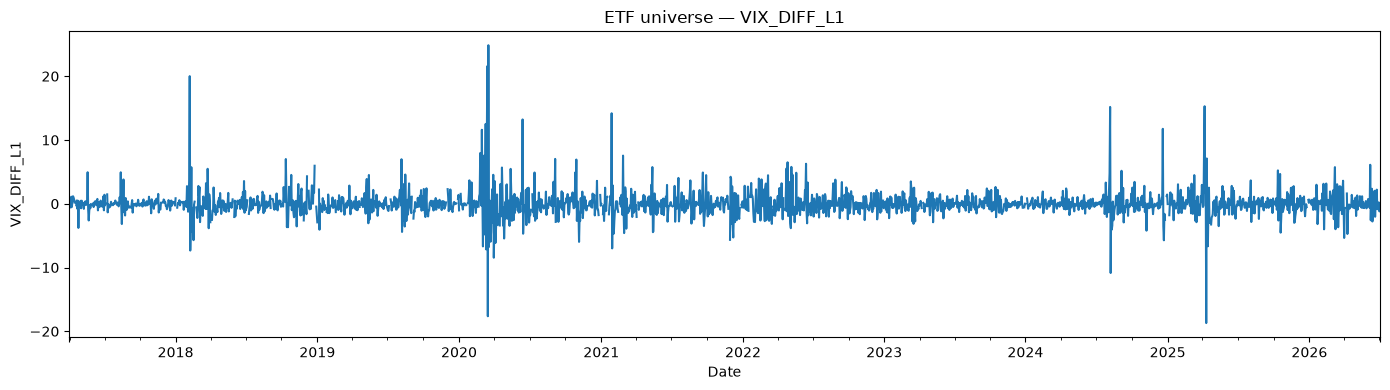

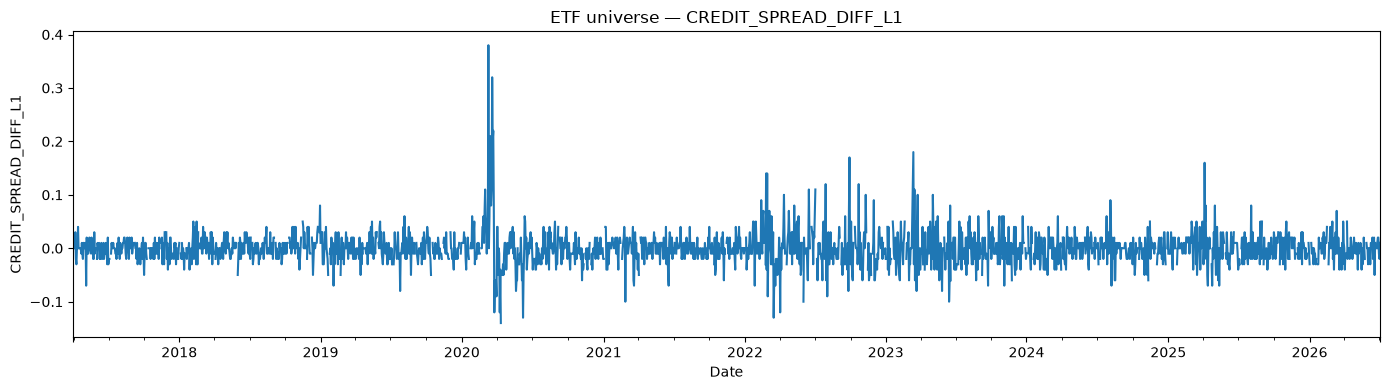

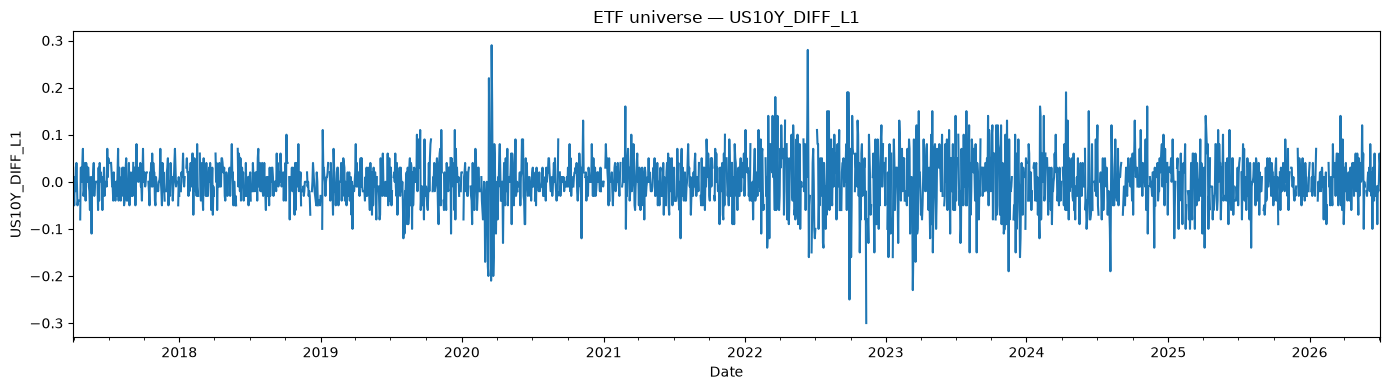

In [56]:
preferred_macro_columns = [
    column
    for column in [
        "VIX_DIFF_L1",
        "CREDIT_SPREAD_DIFF_L1",
        "US10Y_DIFF_L1",
    ]
    if column in etf_features.columns
]

for column in preferred_macro_columns:
    ax = etf_features[column].plot(
        figsize=(14, 4),
        title=f"ETF universe — {column}",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()

## 11. Data-quality checks

In [57]:
missing_values = pd.DataFrame(
    {
        "ETF_NaN": etf_features.isna().sum(),
        "Full_NaN": full_features.isna().sum(),
    }
).fillna(0).astype(int)

missing_values

,ETF_NaN,Full_NaN
MARKET_RETURN,0,0
MARKET_VOL_SHORT,0,0
MARKET_VOL_LONG,0,0
AVG_PAIRWISE_CORR,0,0
CROSS_SECTIONAL_DISPERSION,0,0
MARKET_DRAWDOWN,0,0
VIX_DIFF_L1,116,34
US10Y_DIFF_L1,202,110
DXY_DIFF_L1,207,108
CREDIT_SPREAD_DIFF_L1,212,116


In [58]:
quality_summary = pd.DataFrame(
    {
        "Universe": ["ETF 2017+", "Full 2021+"],
        "Infinite values": [
            int(
                np.isinf(
                    etf_features.select_dtypes(include="number")
                ).sum().sum()
            ),
            int(
                np.isinf(
                    full_features.select_dtypes(include="number")
                ).sum().sum()
            ),
        ],
        "Duplicated dates": [
            int(etf_features.index.duplicated().sum()),
            int(full_features.index.duplicated().sum()),
        ],
        "Sorted index": [
            etf_features.index.is_monotonic_increasing,
            full_features.index.is_monotonic_increasing,
        ],
    }
)

quality_summary

,Universe,Infinite values,Duplicated dates,Sorted index
0,ETF 2017+,0,0,True
1,Full 2021+,0,0,True


## 12. Reproducibility manifest

In [59]:
manifest

{'core_features': {'AVG_PAIRWISE_CORR': 'Mean off-diagonal trailing asset correlation.',
  'CROSS_SECTIONAL_DISPERSION': 'Same-day standard deviation across asset returns.',
  'MARKET_DRAWDOWN': 'Drawdown of cumulative equal-weight market wealth.',
  'MARKET_RETURN': 'Equal-weight cross-asset mean log-return.',
  'MARKET_VOL_LONG': 'Annualized longer trailing volatility of MARKET_RETURN.',
  'MARKET_VOL_SHORT': 'Annualized trailing volatility of MARKET_RETURN.'},
 'global_standardization': False,
 'parameters': {'correlation_min_periods': 42,
  'correlation_window': 63,
  'macro_lag_days': 1,
  'manifest_path': 'data/gold/ml_features_manifest.json',
  'volatility_long_window': 63,
  'volatility_short_window': 21},
 'pipeline': 'phase3_ml_features',
 'standardization_policy': 'Fit scaling only inside each Phase 4 strategy.fit training window.',
 'universes': {'etf_2017': {'columns': ['MARKET_RETURN',
    'MARKET_VOL_SHORT',
    'MARKET_VOL_LONG',
    'AVG_PAIRWISE_CORR',
    'CROSS_SECT

In [60]:
manifest_text = json.dumps(manifest).lower()

assert "global_standardization" in manifest_text
assert "false" in manifest_text

print("Manifest confirms that global standardization is disabled.")

Manifest confirms that global standardization is disabled.


## Conclusions and limitations

- The Phase 3 feature pipeline was executed for the ETF-only and full
  nine-asset universes.
- Rolling statistics use only current and past observations.
- Macroeconomic variables are differenced and lagged by at least one day.
- No global standardization is applied.
- Feature scaling will be fitted only inside each Phase 4 walk-forward
  training window.
- The ETF universe contains the COVID-19 crisis and the 2022 rate shock.
- The full universe starts in 2021 because of the available BVC history.
- The engineered variables characterize market conditions, but no causal
  crisis-prediction claim is made at this stage.